# 04 — Strategy Backtest: SMA Crossover vs Buy & Hold

Backtest chiến lược giao dịch SMA Crossover, đánh giá bằng các chỉ số
chuẩn ngành quant (Sharpe Ratio, Max Drawdown).

**Input**: `data/processed/stock_prices_features.csv`
**Output**: `outputs/strategy_comparison.csv`, `data/processed/backtest_results.csv`

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.backtest import (
    generate_sma_crossover_signals, run_backtest, compute_performance_metrics,
    compare_strategy_vs_buyhold
)

sns.set_style("whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_csv("../data/processed/stock_prices_features.csv", parse_dates=["Date"])
df = df.dropna(subset=["SMA_20", "SMA_50"]).reset_index(drop=True)

## 1. Chiến lược SMA Crossover

- **Golden Cross**: SMA ngắn hạn cắt LÊN TRÊN SMA dài hạn → tín hiệu MUA
- **Death Cross**: SMA ngắn hạn cắt XUỐNG DƯỚI SMA dài hạn → tín hiệu BÁN

**QUAN TRỌNG - tránh look-ahead bias**: tín hiệu tính từ dữ liệu ngày `t`
CHỈ được dùng để giao dịch ở ngày `t+1` — không thể mua/bán ngay trong ngày
phát sinh tín hiệu bằng chính giá đóng cửa của ngày đó, vì tại thời điểm
thị trường vẫn đang mở, chưa biết giá đóng cửa là bao nhiêu.

In [2]:
df_signals = generate_sma_crossover_signals(df, short_window=20, long_window=50)
df_signals[["Date", "Close", "SMA_20", "SMA_50", "Signal", "Position"]].tail(10)

,Date,Close,SMA_20,SMA_50,Signal,Position
691,2024-11-04,210.1800,212.6645,218.3720,0,0.0000
692,2024-11-05,215.1200,212.5375,217.9232,0,0.0000
693,2024-11-06,218.3100,212.5240,217.5836,0,0.0000
694,2024-11-07,218.7400,212.7040,217.6950,0,0.0000
695,2024-11-08,219.7800,213.0735,217.7886,0,0.0000
696,2024-11-11,219.1200,213.5005,218.0476,0,0.0000
697,2024-11-12,207.4200,213.3750,218.0796,0,0.0000
698,2024-11-13,203.4300,212.9555,217.9984,0,0.0000
699,2024-11-14,209.9400,212.7815,218.0974,0,0.0000
700,2024-11-15,214.5900,212.7785,218.1900,0,0.0000


## 2. Chạy Backtest — có trừ phí giao dịch

Phí giao dịch (0.1%/lần đổi vị thế) là yếu tố nhiều người mới làm backtest
bỏ qua — nếu không trừ phí, chiến lược giao dịch nhiều lần có vẻ sinh lời
nhưng thực tế có thể lỗ vì phí ăn hết lợi nhuận.

In [3]:
df_backtest = run_backtest(df_signals, transaction_cost=0.001, initial_capital=10000)

n_trades = (df_backtest["PositionChange"] > 0).sum()
print(f"Số lần đổi vị thế (giao dịch): {n_trades}")
print(f"Tổng phí giao dịch: ${(df_backtest['TransactionCost'] * 10000).sum():.2f} (ước tính trên vốn $10,000)")

Số lần đổi vị thế (giao dịch): 16
Tổng phí giao dịch: $160.00 (ước tính trên vốn $10,000)


## 3. Đường giá trị danh mục (Equity Curve)

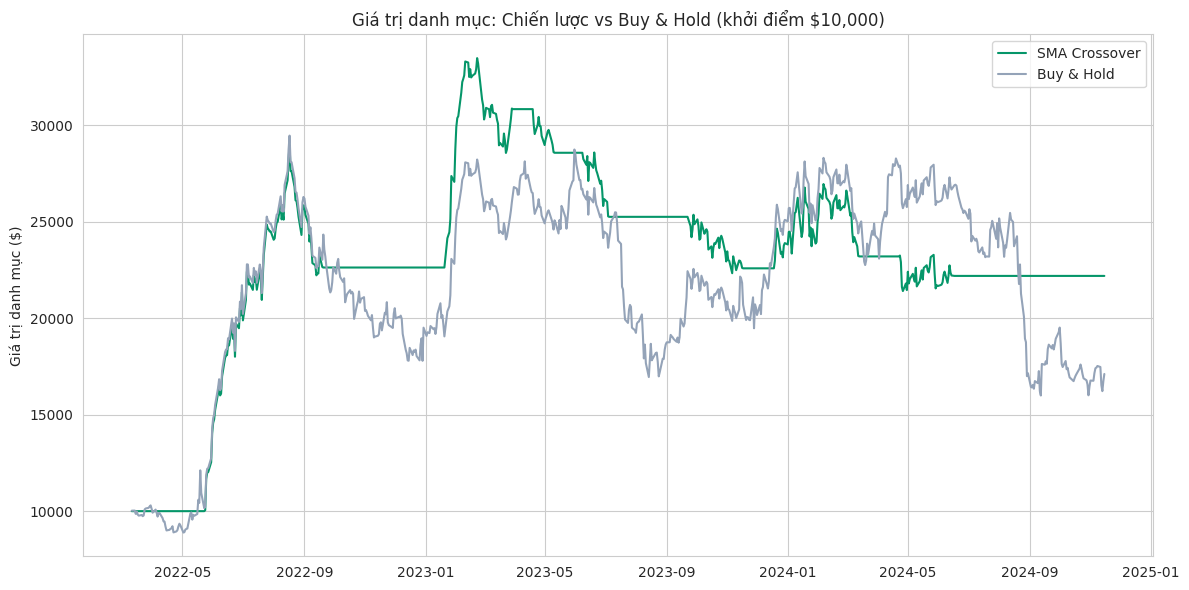

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_backtest["Date"], df_backtest["StrategyEquity"], color="#059669", label="SMA Crossover", linewidth=1.5)
ax.plot(df_backtest["Date"], df_backtest["BuyHoldEquity"], color="#94a3b8", label="Buy & Hold", linewidth=1.5)
ax.set_title("Giá trị danh mục: Chiến lược vs Buy & Hold (khởi điểm $10,000)")
ax.set_ylabel("Giá trị danh mục ($)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/equity_curve.png")
plt.show()

## 4. Đánh giá hiệu năng bằng chỉ số chuẩn ngành quant

- **Sharpe Ratio**: lợi nhuận điều chỉnh theo rủi ro (annualized return /
  annualized volatility) — quan trọng hơn tổng lợi nhuận đơn thuần, vì
  chiến lược rủi ro cao có thể có lợi nhuận cao nhưng không bền vững
- **Max Drawdown**: mức sụt giảm tối đa từ đỉnh — đo khả năng "chịu đựng"
  của chiến lược trong giai đoạn xấu nhất

In [5]:
comparison = compare_strategy_vs_buyhold(df_backtest)
comparison

,Strategy,total_return,annualized_return,annualized_volatility,sharpe_ratio,max_drawdown,win_rate
0,SMA Crossover,1.2199,0.3320,0.3066,1.0828,-0.3606,0.5032
1,Buy & Hold,0.7114,0.2131,0.4708,0.4525,-0.4572,0.5078


**Cách đọc kết quả**: nếu SMA Crossover có Sharpe Ratio cao hơn Buy & Hold
VÀ Max Drawdown ít âm hơn (rủi ro thấp hơn), đây là bằng chứng chiến lược
hoạt động tốt hơn không chỉ về lợi nhuận mà cả về mức độ rủi ro phải chịu.

## 5. Kiểm tra độ nhạy tham số (Parameter Sensitivity)

Một backtest đáng tin cậy cần kiểm tra kết quả có ổn định không khi thay
đổi tham số, tránh trường hợp "overfit" vào đúng 1 cặp tham số may mắn.

In [6]:
results = []
for short_w in [10, 20, 30]:
    for long_w in [50, 80, 100]:
        if short_w >= long_w:
            continue
        df_temp = df.copy()
        df_temp[f"SMA_{short_w}"] = df_temp["Close"].rolling(short_w).mean()
        df_temp[f"SMA_{long_w}"] = df_temp["Close"].rolling(long_w).mean()
        df_temp = df_temp.dropna(subset=[f"SMA_{short_w}", f"SMA_{long_w}"]).reset_index(drop=True)

        sig = generate_sma_crossover_signals(df_temp, short_window=short_w, long_window=long_w)
        bt = run_backtest(sig)
        metrics = compute_performance_metrics(bt, return_col="StrategyReturnNet")
        results.append({"short_window": short_w, "long_window": long_w, **metrics})

sensitivity_df = pd.DataFrame(results)
sensitivity_df[["short_window", "long_window", "sharpe_ratio", "total_return", "max_drawdown"]].sort_values(
    "sharpe_ratio", ascending=False
)

,short_window,long_window,sharpe_ratio,total_return,max_drawdown
3,20,50,1.1356,1.2199,-0.3606
0,10,50,0.9520,1.0289,-0.3324
6,30,50,0.7364,0.6904,-0.3710
7,30,80,0.1140,0.0846,-0.3133
1,10,80,-0.0495,-0.0365,-0.3109
4,20,80,-0.0854,-0.0618,-0.3427
8,30,100,-0.1346,-0.0899,-0.3364
2,10,100,-0.1529,-0.0987,-0.3026
5,20,100,-0.3105,-0.2030,-0.3602


**Nhận xét**: nếu Sharpe Ratio ổn định (không dao động quá lớn) qua nhiều
cặp tham số khác nhau, chiến lược đáng tin cậy hơn. Nếu chỉ 1 cặp tham số
cụ thể cho kết quả tốt vượt trội còn lại đều kém, đó là dấu hiệu cảnh báo
overfitting vào dữ liệu lịch sử — chiến lược khó hoạt động tốt trên dữ liệu
tương lai.

## 6. Lưu kết quả

In [7]:
comparison.to_csv("../outputs/strategy_comparison.csv", index=False)
df_backtest.to_csv("../data/processed/backtest_results.csv", index=False)
sensitivity_df.to_csv("../outputs/parameter_sensitivity.csv", index=False)
print("Đã lưu kết quả backtest và phân tích độ nhạy tham số")

Đã lưu kết quả backtest và phân tích độ nhạy tham số
